# Generating VAE Embeddings

In [1]:
import torch

# DTYPE = torch.float16
DTYPE = torch.float32

if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Using device: {device}")

Using device: cuda


In [2]:
import os
from huggingface_hub import login
token = os.environ.get("HF_TOKEN")
login(token=token)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [3]:
from diffusers import AutoencoderKL

# Load only the VAE part of the Flux model (no full diffusion pipeline)
vae = AutoencoderKL.from_pretrained(
    "black-forest-labs/FLUX.1-dev",
    subfolder="vae",    
    torch_dtype=DTYPE
).to(device)  

In [5]:
# save weights
save_path = os.path.join("data", "model_weights", "vae")
vae.save_pretrained(save_path)

In [4]:
from PIL import Image
from io import BytesIO
import numpy as np

path = f"../scratch/partial_datasets/realestate10k/train/0c6c060f599465ed/images/59959900.png"
img = Image.open(path).convert("RGB")
# img = img.resize((1024, 1024), Image.LANCZOS)
print(img.size)   # (width, height)
print(np.array(img).shape)  # (H, W, 3)

(640, 360)
(360, 640, 3)


In [5]:
img_tensor = torch.tensor(np.array(img))
# assuming img_tensor is shape (3, H, W) or (1, 3, H, W)
if img_tensor.dtype != torch.float32:
    img_tensor = img_tensor.float()

# normalize to [-1, 1]
img_tensor = img_tensor / 255.0  # 0–1
img_tensor = img_tensor * 2 - 1  # -> [-1, 1]

# ensure correct shape
if img_tensor.ndim == 3:
    img_tensor = img_tensor.unsqueeze(0)

# move to correct device
img_tensor = img_tensor.permute(0, 3, 1, 2).to(device)

img_tensor.shape  # (1, 3, H, W)

torch.Size([1, 3, 360, 640])

In [6]:
vae.eval()
img_tensor = img_tensor.to(device,dtype=DTYPE)
with torch.no_grad():
    out = vae.encode(img_tensor)
    latent_dist = out.latent_dist
    # Use the mean instead of a random sample to remove noise
    z = latent_dist.mean  
z.shape  # (1, latent_channels, H/8, W/8)

torch.Size([1, 16, 45, 80])

In [8]:
# torch.save(z, "tmp.pt")
z

tensor([[[[ 2.0198,  0.8947,  0.8760,  ...,  3.2320, -0.0184,  0.9042],
          [ 1.4485,  0.0167,  0.3433,  ...,  1.3128,  0.6401,  2.4757],
          [ 2.9326,  1.5456,  1.2680,  ...,  2.5664,  0.2015,  1.2111],
          ...,
          [ 0.5154,  0.5714,  0.9065,  ...,  1.0893, -0.7185, -0.4034],
          [ 0.7375,  1.6473,  0.9049,  ...,  0.6460,  0.4930,  1.4690],
          [ 0.0133,  0.7401,  0.1905,  ...,  0.2376,  0.7500,  0.7671]],

         [[ 7.1466,  5.5278,  5.0873,  ...,  1.3760,  7.5903,  4.8325],
          [ 8.3723,  8.6654, 10.2743,  ...,  6.9247,  8.2548,  8.8387],
          [ 5.5824,  6.4889,  6.8107,  ...,  5.1947,  7.8475,  5.3975],
          ...,
          [-5.1421, -5.4817, -6.3512,  ...,  4.0158,  3.2715,  1.3954],
          [-4.2537, -5.4907, -5.3673,  ...,  5.8003,  3.2939,  4.1964],
          [-3.9871, -4.4059, -4.5238,  ...,  0.9036,  1.8017, -0.0567]],

         [[-1.4150,  0.7193,  0.5317,  ..., -3.5013, -2.0807,  1.1278],
          [-0.9989, -0.5659, -

In [9]:
# run on device (GPU)

vae32 = AutoencoderKL.from_pretrained(
    "black-forest-labs/FLUX.1-dev",
    subfolder="vae"    
).to(device)  


with torch.no_grad():
    reconstructed = vae32.decode(z.float()).sample

# force to run on CPU
# vae = vae.to("cpu")
# with torch.no_grad():
#     reconstructed = vae.decode(z.to("cpu")).sample

reconstructed.shape  # (1, 3, H, W)

torch.Size([1, 3, 360, 640])

In [ ]:
reconstructed

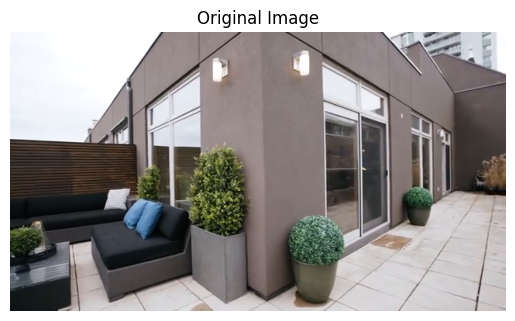

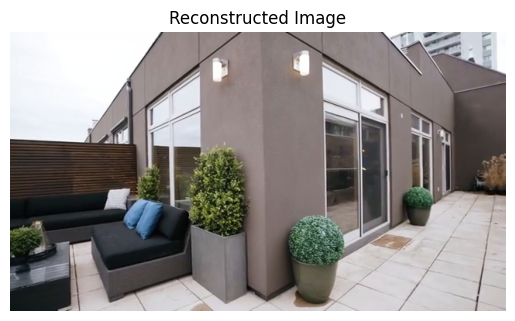

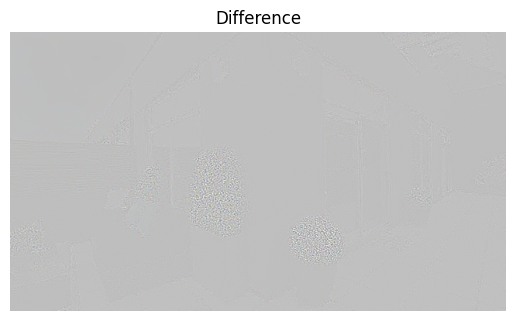

In [9]:
import torch
import matplotlib.pyplot as plt

def show_tensor(tensor, title=None):
    """
    Display a single image tensor using matplotlib.
    Works for:
      - [3, H, W] RGB tensors
      - [1, H, W] grayscale tensors
      - [B, 3, H, W] -> shows the first image in the batch

    Args:
        tensor (torch.Tensor): Image tensor to display.
        title (str, optional): Optional title for the plot.
    """
    # Move to CPU and detach from graph
    tensor = tensor.detach().cpu()

    # Handle batch dimension
    if tensor.dim() == 4:
        tensor = tensor[0]

    # If normalized to [-1, 1], convert back to [0, 1]
    if tensor.min() < 0:
        tensor = (tensor + 1) / 2

    # Clamp to [0, 1] just in case
    tensor = tensor.clamp(0, 1)

    # Convert from (C, H, W) → (H, W, C)
    if tensor.shape[0] == 3:
        img = tensor.permute(1, 2, 0).numpy()
        plt.imshow(img)
    elif tensor.shape[0] == 1:
        img = tensor.squeeze(0).numpy()
        plt.imshow(img, cmap="gray")
    else:
        raise ValueError(f"Unsupported tensor shape: {tensor.shape}")

    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

show_tensor(img_tensor.float(), title="Original Image")
show_tensor(reconstructed.float(), title="Reconstructed Image")
show_tensor(img_tensor.float() - reconstructed.float() + 0.5, title="Difference")

In [13]:
# MSE between originaland reconstructed
mse_loss = torch.nn.MSELoss()
mse = mse_loss(img_tensor.cpu(), reconstructed.cpu())
print(f"MSE Loss: {mse.item():.6f}")

MSE Loss: 0.001376


# Original Data Processing Pipeline

In [3]:
from typing import Tuple
import cv2
import numpy as np

def resize_crop_with_subpixel_accuracy(
    image: np.ndarray, K: np.ndarray, patch_size: int
) -> Tuple[np.ndarray, np.ndarray]:
    """Resize and crop the image to have the smallest side equal to `patch_size`,
    while maintaining sub-pixel accuracy using a single warpAffine transformation.

    Args:
        image (np.ndarray): Input image.
        K (np.ndarray): Camera intrinsic matrix.
        patch_size (int): Target size of the smaller dimension.

    Returns:
        Tuple[np.ndarray, np.ndarray]: Resized and cropped image, updated intrinsic matrix.
    """
    h, w = image.shape[:2]
    scale = patch_size / min(h, w)

    # Compute the affine transformation matrix combining scaling and cropping
    new_w, new_h = w * scale, h * scale
    crop_x = (new_w - patch_size) / 2
    crop_y = (new_h - patch_size) / 2

    M = np.array([[scale, 0, -crop_x], [0, scale, -crop_y]], dtype=np.float32)

    # Apply affine transformation with sub-pixel accuracy
    is_downsampling = min(h, w) > patch_size
    interpolation = cv2.INTER_AREA if is_downsampling else cv2.INTER_CUBIC
    cropped_resized_image = cv2.warpAffine(
        image, M, (patch_size, patch_size), flags=interpolation
    )

    # Update intrinsic matrix K
    K_scaled = K.copy()
    K_scaled[:2, :] *= scale
    K_scaled[0, 2] -= crop_x
    K_scaled[1, 2] -= crop_y

    return cropped_resized_image, K_scaled


def center_zoom_in_with_subpixel_accuracy(
    image: np.ndarray, K: np.ndarray, scale: float = 1.0
) -> Tuple[np.ndarray, np.ndarray]:
    """Zoom into the center of the image while maintaining sub-pixel accuracy using warpAffine.

    Args:
        image (np.ndarray): Input image.
        K (np.ndarray): Camera intrinsic matrix.
        scale (float): Zoom-in factor.

    Returns:
        Tuple[np.ndarray, np.ndarray]: Zoomed image, updated intrinsic matrix.
    """
    if scale == 1.0:
        return image, K

    h, w = image.shape[:2]
    center_x, center_y = w / 2, h / 2

    # Compute the affine transformation matrix for zooming in at the center
    M = np.array(
        [[scale, 0, (1 - scale) * center_x], [0, scale, (1 - scale) * center_y]],
        dtype=np.float32,
    )

    # Apply affine transformation
    zoomed_image = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_AREA)

    # Update intrinsic matrix K.
    K_zoomed = K.copy()
    K_zoomed[:2, :] *= scale
    K_zoomed[0, 2] += (1 - scale) * center_x
    K_zoomed[1, 2] += (1 - scale) * center_y

    return zoomed_image, K_zoomed

In [4]:
# adjusted from nvs / dataset.py
from typing import Union, Dict, Any, List
import imageio.v2 as imageio


import glob
import json
import os
import random
from typing import Any, Dict, List, Optional, Tuple, Union

import cv2
import imageio.v2 as imageio
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

def load_frames_from_meta_info(
    data_dir: str,
    meta_info: Dict[str, Any],
    frame_ids: List[int],
    patch_size: int = 256,
    zoom_factor: float = 1.0,
    random_zoom: bool = False,
    camera_pose_only: bool = False,
) -> Union[Dict[str, Any], np.ndarray]:
    blender2opencv = np.array(
        [[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]]
    )

    # Load the camera intrinsic
    K_raw = np.array(
        [
            [meta_info["fl_x"], 0, meta_info["cx"]],
            [0, meta_info["fl_y"], meta_info["cy"]],
            [0, 0, 1],
        ],
        dtype=np.float32,
    )
    frames = meta_info["frames"]

    # Shortcut for loading only camera poses
    if camera_pose_only:
        c2ws = []
        for frame_id in frame_ids:
            frame = frames[frame_id]
            c2w = np.array(frame["transform_matrix"], dtype=np.float32) @ blender2opencv
            c2ws.append(c2w)
        return np.stack(c2ws)

    # Load the images
    images, Ks, c2ws, abs_image_paths = [], [], [], []

    for index, frame_id in enumerate(frame_ids):
        frame = frames[frame_id]

        rel_image_path = frame["file_path"]
        abs_image_path = os.path.join(data_dir, rel_image_path)
        image = imageio.imread(abs_image_path)[..., :3]

        per_image_zoom_factor = (
            np.random.uniform(1.0, zoom_factor) if random_zoom else zoom_factor
        )

        image, K = center_zoom_in_with_subpixel_accuracy(
            image,
            K_raw,
            per_image_zoom_factor,
        )
        image, K = resize_crop_with_subpixel_accuracy(image, K, patch_size)

        c2w = np.array(frame["transform_matrix"], dtype=np.float32) @ blender2opencv

        images.append(image)
        Ks.append(K)
        c2ws.append(c2w)
        abs_image_paths.append(abs_image_path)

    return {
        "image": np.stack(images),
        "K": np.stack(Ks),
        "camtoworld": np.stack(c2ws),
        "image_path": abs_image_paths,
    }

def load_and_maybe_update_meta_info(json_path: str) -> Tuple[bool, Dict]:
    """Load the meta information from the `transforms.json` file.

    If the image paths (e.g., `images/xxx.jpg` ) stored in the `transforms.json` file
    are not found, try with `images_{1, 2, 4, 8}/xxx.jpg` instead, and update the
    camera intrinsics accordingly.
    """
    if not os.path.exists(json_path):
        return False, {}
    with open(json_path, "r") as f:
        meta_info = json.load(f)

    # Check if the image paths are valid
    frames = meta_info["frames"]
    if len(frames) == 0:
        return False, {}

    # Use the jpg version if it exists (for DL3DV)
    if "-jpeg" in json_path:
        for frame in frames:
            frame["file_path"] = os.path.splitext(frame["file_path"])[0] + ".jpeg"

    # Check if the image paths are valid
    maybe_relative_path_to_img = frames[0]["file_path"]
    if maybe_relative_path_to_img.startswith("/"):
        _start_path = os.path.abspath(os.path.dirname(json_path))
        for frame in frames:
            frame["file_path"] = os.path.relpath(frame["file_path"], start=_start_path)
        relative_path_to_img = frames[0]["file_path"]
    else:
        relative_path_to_img = maybe_relative_path_to_img

    abs_path_to_img = os.path.join(os.path.dirname(json_path), relative_path_to_img)
    if not os.path.exists(abs_path_to_img):
        # Try with images_{1, 2, 4, 8}/xxx.jpg
        assert (
            "images/" in relative_path_to_img
        ), f"Invalid image path in the meta info file: {relative_path_to_img}"
        factor = None
        for _factor in [1, 2, 4, 8]:
            _relative_path_to_img = relative_path_to_img.replace(
                "images/", f"images_{_factor}/"
            )
            _abs_path_to_img = os.path.join(
                os.path.dirname(json_path), _relative_path_to_img
            )
            if os.path.exists(_abs_path_to_img):
                factor = _factor
                break

        if factor is None:
            # No valid image path found
            return False, meta_info

        # Found a valid image path, update the meta info
        for frame in frames:
            frame["file_path"] = frame["file_path"].replace(
                "images/", f"images_{factor}/"
            )

        w, h = meta_info["w"], meta_info["h"]
        assert (
            w % factor == 0 and h % factor == 0
        ), f"Invalid factor: {factor} with w={w} and h={h}"

        for key in ["fl_x", "fl_y", "cx", "cy"]:
            meta_info[key] /= factor
        for key in ["w", "h"]:
            meta_info[key] //= factor

    return True, meta_info

In [9]:
def select_views(
        input_views, supervise_views, n_frames: int, min_frame_dist: int = 25, max_frame_dist: int = 100
    ) -> Optional[List[int]]:
        # From: https://github.com/Haian-Jin/LVSM/blob/ebeff4989a3e1ec38fcd51ae24919d0eadf38c8f/data/dataset_scene.py#L133C1-L149C29
        if n_frames < input_views + supervise_views:
            return None
        max_frame_dist = min(n_frames - 1, max_frame_dist)
        if max_frame_dist <= min_frame_dist:
            return None
        frame_dist = random.randint(min_frame_dist, max_frame_dist)
        if n_frames <= frame_dist:
            return None
        start_index = random.randint(0, n_frames - frame_dist - 1)
        end_index = start_index + frame_dist
        supervise_indices = random.sample(
            range(start_index + 1, end_index), supervise_views
        )
        indices = [start_index, end_index] + supervise_indices
        return indices

In [11]:
data_dir = f"../data_processed/realestate10k/train/0c6c060f599465ed"
valid, meta_info = load_and_maybe_update_meta_info(
    os.path.join(data_dir, "transforms.json")
)
assert valid, f"Invalid scene: {data_dir}"

# manual
input_views = 2
supervise_views = 1

n_frames = len(meta_info["frames"])

# 
frame_ids = select_views(input_views, supervise_views, n_frames)
 


loaded = load_frames_from_meta_info(
    data_dir,
    meta_info,
    frame_ids,
    # patch_size - default 256
    # zoom_factor - default 1
    # random_zoom - default false
)

In [ ]:
imgs = loaded['image']

img_tensor = torch.tensor(imgs[1]).permute(2,1,0)
img_tensor = img_tensor / 255.0  # 0–1
img_tensor = img_tensor * 2 - 1  # -> [-1, 1]

# show_tensor(img_tensor.float(), title="Img 0")
# print(img_tensor.shape)
# print(loaded["camtoworld"].shape) # n x 4 x 4 Transformationsmatrix

print(loaded["K"][0]) # n x 3 x 3 K-Matrix

[[220.65358   0.      128.     ]
 [  0.      220.65356 128.     ]
 [  0.        0.        1.     ]]


# Helper Fncs

## rename files to .pt

In [9]:
import json

path = "../data_processed/realestate10k_latent/train/0c6c060f599465ed/transforms.json"

with open(path, "r") as f:
    data = json.load(f)

text = json.dumps(data)
text = text.replace(".png", ".pt")
data_new = json.loads(text)

with open(path, "w") as f:
    json.dump(data_new, f, indent=2)

print("All .png paths replaced with .pt in", path)

All .png paths replaced with .pt in ../data_processed/realestate10k_latent/train/0c6c060f599465ed/transforms.json
